### EfficientNet-B0 Architecture Implementation

**AIM**: Build and train an image classifier to detect images using a Vanilla EfficientNet-B0 Architecture.

### EfficientNet-B0 Architecture Implementation

**AIM**: Build and train an image classifier to detect images using a Vanilla EfficientNet-B0 Architecture.

### Objectives
- Data visualisation
- Data preprocessing and image augmentation
- Build a Vanilla EfficientNet-B0 Model for Image Classification
- Compile and train the model
- Add early stopping callback (optional)
- Save and load model
- Model evaluation
- Make prediction on new data

### Prerequisite
- Google colab or Jupyter notebook
- dogs-cats-classification-dataset
- TensorFlow2

### Check if TensorFlow, NumPy, Pandas and Matplotlib are installed

In [1]:
!pip show tensorflow

Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /home/agbor/anaconda3/envs/tf/lib/python3.11/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: spektral, tensorflow-gnn, tensorflow-text, tf_keras


In [2]:
# !pip show numpy

In [3]:
# !pip show pandas

In [4]:
!pip show matplotlib

Name: matplotlib
Version: 3.7.5
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: matplotlib-users@python.org
License: PSF
Location: /home/agbor/anaconda3/envs/tf/lib/python3.11/site-packages
Requires: contourpy, cycler, fonttools, kiwisolver, numpy, packaging, pillow, pyparsing, python-dateutil
Required-by: captum, catboost, missingno, pandas-profiling, phik, pycaret, pyod, pytorch-tabular, SALib, scikit-plot, seaborn, wordcloud, ydata-profiling, yellowbrick


In [5]:
import os
import sys
import random
import pathlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

2026-02-17 13:45:39.102341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771332339.117084  340580 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771332339.121668  340580 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771332339.132802  340580 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771332339.132818  340580 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771332339.132820  340580 computation_placer.cc:177] computation placer alr

In [6]:
# Set seed for reproducibility

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
# Check for GPU
!nvidia-smi

Tue Feb 17 13:45:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 4000                Off |   00000000:01:00.0 Off |                  N/A |
| N/A   71C    P8              8W /  110W |       6MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
# Check if TensorFlow can detect any GPU
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"GPUs available: {len(gpus)}")

    for gpu in gpus:
        print(f"- {gpu}")
else:
    print("No GPUs found.")

GPUs available: 1
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [9]:
gpus = tf.config.list_physical_devices("GPU")
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [10]:
# Get the total number of GPUs and names
if gpus:
    print(f"Total number of GPUs: {len(gpus)}")
    
    for gpu in gpus:
        print(f"GPU Name: {gpu}")
else:
    print("No GPU available")

Total number of GPUs: 1
GPU Name: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [11]:
# Check TensorFlow version
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [12]:
# CReate a director called "models" to store model files during training

if not os.path.isdir("models"):
    os.mkdir("models")

In [13]:
## Set the base path
base_dir = "../../datasets/dog_vs_cats"
base_dir = pathlib.Path(base_dir)
base_dir

PosixPath('../../datasets/dog_vs_cats')

In [14]:
# Train directory
train_dir = base_dir / "train"
train_dir

PosixPath('../../datasets/dog_vs_cats/train')

In [15]:
# Validation directory
test_dir = base_dir / "test"
test_dir

PosixPath('../../datasets/dog_vs_cats/test')

In [16]:
# Validation directory
validation_dir = base_dir / "validation"
validation_dir

PosixPath('../../datasets/dog_vs_cats/validation')

In [17]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 16
EPOCHS = 2000

In [18]:
# Load the training dataset
# Using `image_dataset_from_directory (recommended and stable)
# Instead of using the 'ImageDataGenerator()' class

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
)

Found 20000 files belonging to 2 classes.


I0000 00:00:1771332341.487870  340580 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6624 MB memory:  -> device: 0, name: Quadro RTX 4000, pci bus id: 0000:01:00.0, compute capability: 7.5


In [19]:
# Load the validation dataset

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
)

Found 5000 files belonging to 2 classes.


In [20]:
# Load the validation dataset

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
)

Found 12461 files belonging to 2 classes.


In [21]:
# Get the class names
class_names = train_dataset.class_names
number_classes = len(class_names)

print(f"Number of classes: {number_classes}")
print(f"Class names: {list(class_names)}")

Number of classes: 2
Class names: ['cats', 'dogs']


### Sanity Check: Visualise dataset samples 
- Confirms correct labels
- Detects corrupt images
- Verifies colour channels, orientation, resolution

In [22]:
# Verify (test)

train_dataset.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [23]:
# Capture exactly ONE batch and store it in memory
# This "freezes" the random augmentations for this specific set
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

2026-02-17 13:45:42.709968: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


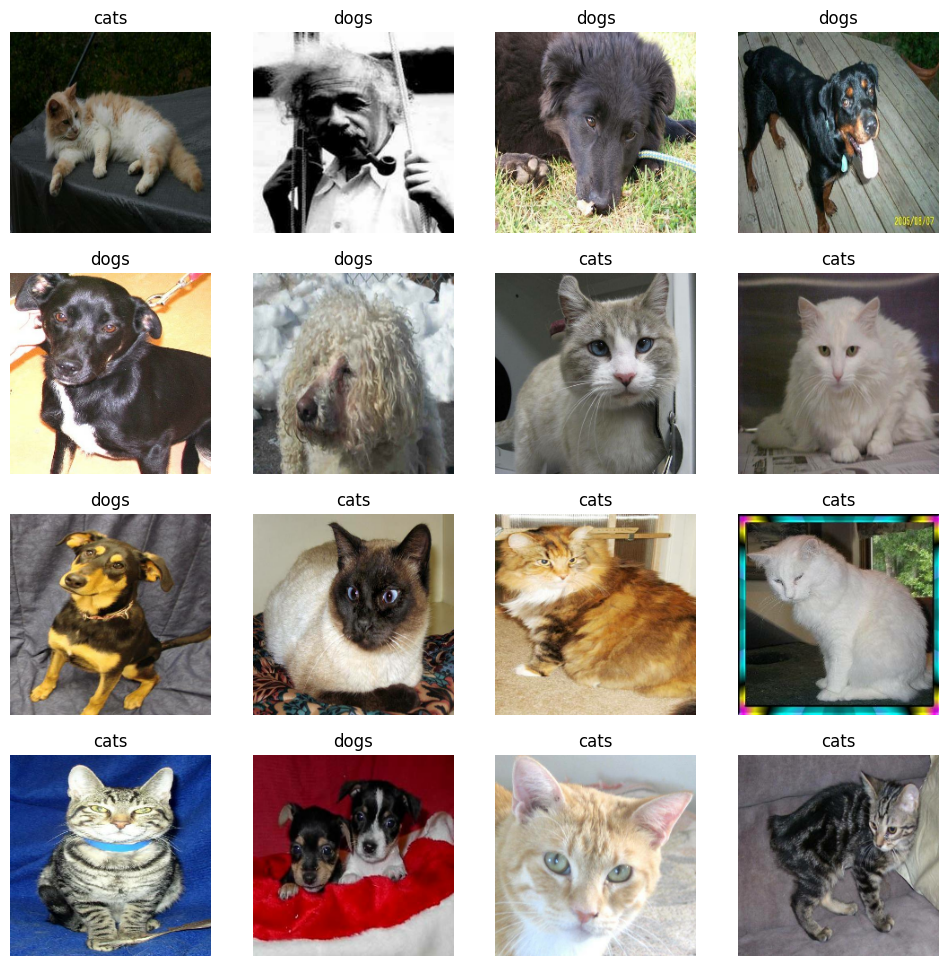

In [24]:
# Visualisation
# No matter how many times you run this cell, the images won't change.
plt.figure(figsize=(12, 12))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype("uint8"))
    plt.title(class_names[fixed_labels[i]])
    plt.axis("off")

### Performance Optimisation

Using `tf.data.AUTOTUNE` and the specific method below creates an asynchronous pipeline—basically, it allows the CPU to prepare the next batch while the GPU is still processing the current one.

In [25]:
# AUTOTUNE allows TensorFlow to dynamically adjust the resource allocation 
# (like CPU threads) based on your hardware's current workload at runtime.
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    # Keep the data in memory (RAM) after the first epoch.
    # This prevents the CPU from having to re-read and re-decode JPEGs 
    # from the slow hard drive during every subsequent training round.
    .cache()

    # Maintain a buffer of 1,000 samples and randomly pulls from it.
    # This ensures the model doesn't learn the order of the files, 
    # but rather the features of the images.
    .shuffle(1000)

    # Overlaps the data preprocessing and model execution.
    # While the GPU is training on the current batch, the CPU is already 
    # preparing the next batch in the background. This eliminates "GPU starvation."
    .prefetch(buffer_size=AUTOTUNE)
)

In [26]:
validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

In [27]:
test_dataset = (
    test_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

### Data Augmentation (Modern Keras Layers)

In [28]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [29]:
# Input shape
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH) + (3,)

### Squeeze-and-Excitation Block

In [30]:
def squeeze_excite_block(inputs, se_ratio=0.25):
    filters = inputs.shape[-1]
    reduced_filters = max(1, int(filters * se_ratio))

    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Reshape((1, 1, filters))(x)
    x = tf.keras.layers.Dense(reduced_filters, activation="relu")(x)
    x = tf.keras.layers.Dense(filters, activation="sigmoid")(x)
    return tf.keras.layers.multiply([inputs, x])

### MBConv Block

In [31]:
from tensorflow.keras import layers, models

In [32]:
def mbconv_block(inputs,
                 filters,
                 kernel_size,
                 strides,
                 expand_ratio,
                 se_ratio=0.25,
                 drop_rate=0.2):
    in_channels = inputs.shape[-1]
    x = inputs

    # Expansion phase
    expanded_channels = in_channels * expand_ratio
    if expand_ratio != 1:
        x = layers.Conv2D(expanded_channels, 1, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("swish")(x)

    # Depthwise convolution
    x = layers.DepthwiseConv2D(kernel_size, strides=strides, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    # Squeeze-and-Excitation
    x = squeeze_excite_block(x, se_ratio)

    # Projetion phase
    x = layers.Conv2D(filters, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Skip connection
    if strides == 1 and in_channels == filters:
        if drop_rate > 0:
            x = layers.Dropout(drop_rate)(x)
        x = layers.add([x, inputs])

    return x

        

### EfficientNet Builder

In [33]:
def EfficientNet(input_shape=(224, 224, 3), num_classes=1000, width_mult=1.0, depth_mult=1.0, drop_rate=0.2):
    inputs = layers.Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(int(32 * width_mult), 3, strides=2, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    # MBConv configurations (from EfficientNet-B0)
    configs = [
        (1, 16, 3, 1, 1),
        (6, 24, 3, 2, 2),
        (6, 40, 5, 2 ,2),
        (6, 80, 3, 2, 3),
        (6, 112, 5, 1, 3),
        (6, 192, 5, 2, 4),
        (6, 320, 3, 1, 1)
    ]

    # Build MBConv Blocks
    for expand_ratio, filters, kernel_size, strides, repeats in configs:
        filters = int(filters * width_mult)
        repeats = int(repeats * depth_mult)

        for i in range(repeats):
            stride = strides if i == 0 else 1
            x = mbconv_block(x, filters, kernel_size, stride, expand_ratio, drop_rate=drop_rate)

    # Head
    x = layers.Conv2D(int(1280 * width_mult), 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(drop_rate)(x)
    outputs = layers.Dense(num_classes, activation="sigmoid")(x)

    return models.Model(inputs, outputs)


### Build and Compile the Model

In [34]:
model = EfficientNet(input_shape=INPUT_SHAPE,
                     num_classes=1, # For binary classification
                     width_mult=1.0, 
                     depth_mult=1.0)

In [35]:
# Compile the model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

### Configure Callbacks

In [36]:
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/mobilenetv3large2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    # verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=5,
    verbose=1
)


callbacks = [model_checkpoint, early_stopping, reduce_learning_rate]

### Train the model to learn patterns from the images

In [37]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/2000


I0000 00:00:1771332374.799740  340687 service.cc:152] XLA service 0x78b208002c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771332374.799759  340687 service.cc:160]   StreamExecutor device (0): Quadro RTX 4000, Compute Capability 7.5
2026-02-17 13:46:15.502464: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771332378.992912  340687 cuda_dnn.cc:529] Loaded cuDNN version 90501
2026-02-17 13:46:24.475500: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 13:46:24.615979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please in

   3/1250 ━━━━━━━━━━━━━━━━━━━━ 1:10 57ms/step - accuracy: 0.4722 - loss: 1.0270  

I0000 00:00:1771332401.179844  340687 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 139s 67ms/step - accuracy: 0.6380 - loss: 0.6396 - val_accuracy: 0.6740 - val_loss: 0.6079 - learning_rate: 0.0010
Epoch 2/2000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.7307 - loss: 0.5364 - val_accuracy: 0.7614 - val_loss: 0.6632 - learning_rate: 0.0010
Epoch 3/2000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.7976 - loss: 0.4351 - val_accuracy: 0.7754 - val_loss: 0.5376 - learning_rate: 0.0010
Epoch 4/2000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.8390 - loss: 0.3653 - val_accuracy: 0.8544 - val_loss: 0.3355 - learning_rate: 0.0010
Epoch 5/2000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.8713 - loss: 0.3013 - val_accuracy: 0.8482 - val_loss: 0.3854 - learning_rate: 0.0010
Epoch 6/2000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.8957 - loss: 0.2499 - val_accuracy: 0.9026 - val_loss: 0.2192 - learning_rate: 0.0010
Epoch 7/2000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accu

### Plot Training Curves (Learning Dynamics)

In [38]:
def plot_learning_curves(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(len(acc))


    plt.figure(figsize=(18, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()


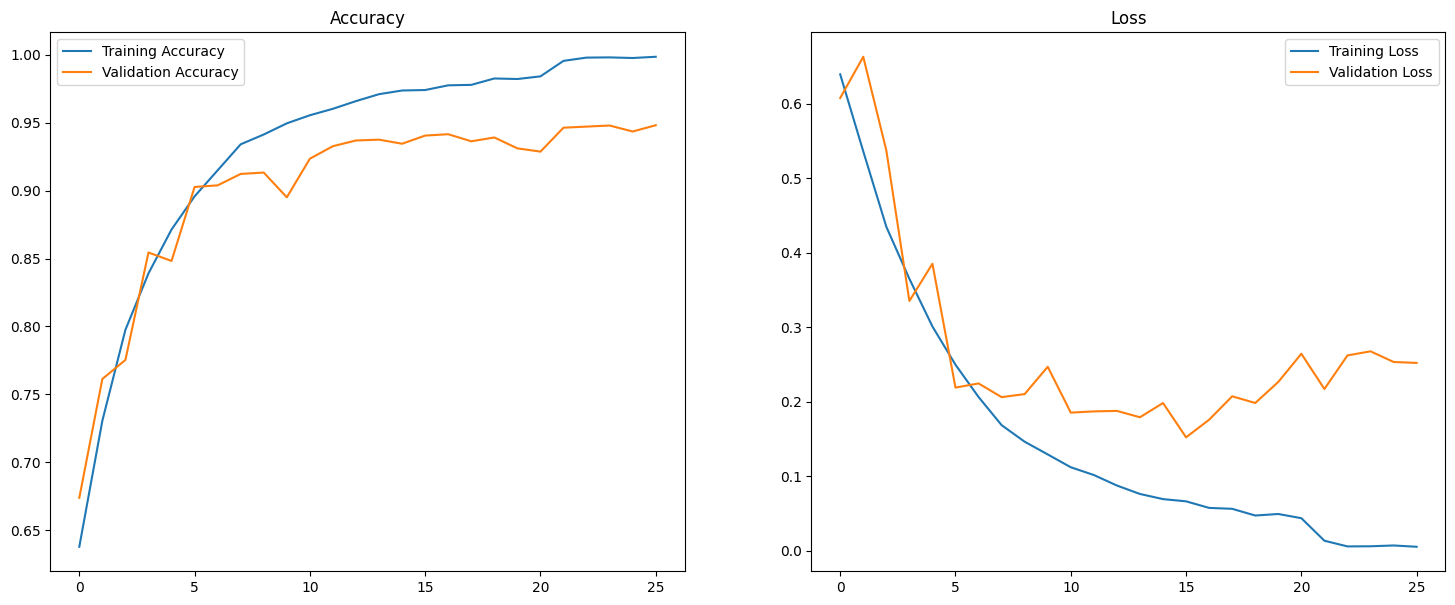

In [39]:
plot_learning_curves(history)

### Generate Predictions (TensorFlow to NumPy)

In [40]:
loss, accuracy = model.evaluate(validation_dataset)

print(f"Model Loss: {loss:.2f}")
print(f"Model Accuracy: {accuracy:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9404 - loss: 0.1525
Model Loss: 0.15
Model Accuracy: 0.94


In [41]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=1) # Try verbose=0
    y_prob.append(preds)
    y_pred.append(preds >= 0.5)
    y_true.append(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━

2026-02-17 14:20:28.858300: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [42]:
len(y_true), len(y_pred), len(y_prob)

(779, 779, 779)

In [43]:
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_prob = np.concatenate(y_prob)

### Core Classification Metrics (from scikit-learn)

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)



print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
print(f"Precision (macro): {precision_score(y_true, y_pred)}")
print(f"Recall (macro): {recall_score(y_true, y_pred):.2f}")
print(f"F1-score (macro): {f1_score(y_true, y_pred):.2f}")

Accuracy: 0.9381269561030415
Precision (macro): 0.9284366152878264
Recall (macro): 0.95
F1-score (macro): 0.94


In [45]:
# Full Classification Report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))


              precision    recall  f1-score   support

        cats     0.9482    0.9271    0.9375      6242
        dogs     0.9284    0.9492    0.9387      6219

    accuracy                         0.9381     12461
   macro avg     0.9383    0.9381    0.9381     12461
weighted avg     0.9383    0.9381    0.9381     12461



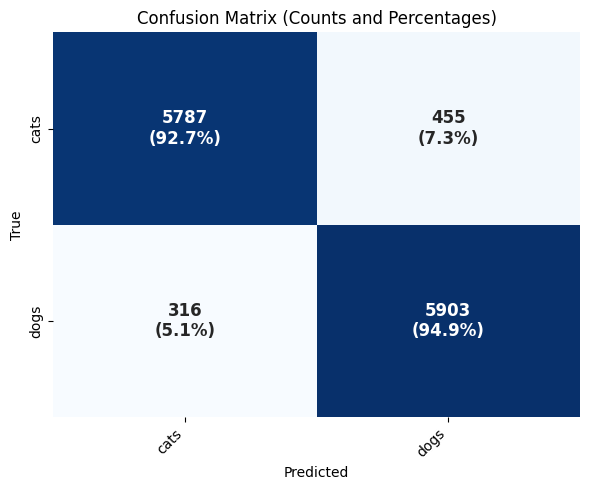

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))

# Create custom annotations showing both count and percentage
annot_text = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot_text[i, j] = f'{cm[i, j]}\n({cm_norm[i, j]:.1%})'

sns.heatmap(cm, 
            cmap="Blues", 
            cbar=False, 
            annot=annot_text, 
            fmt='',  # fmt='' for string annotations
            xticklabels=class_names,
            yticklabels=class_names,
            
            # kwargs for annotation text
            annot_kws={"fontsize": 12, "fontweight": "bold"},)  

plt.title("Confusion Matrix (Counts and Percentages)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")

# Adjust layout to prevent text cutoff
plt.tight_layout()  
plt.show()

In [47]:
# Saving the Model

model.save("dogs_cat_MobileNetV3.keras")

**This resulted in a poor model. We will use transfer learning to see how to improve the model using any of the model which is already doing well in general image processing tasks.**